<a href="https://colab.research.google.com/github/EgorMatveev26/SOTA/blob/main/lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №1: Transfer learning и fine-tuning визуального backbone

**Версия:** студенческая  
**Курс:** «Современное компьютерное зрение»

> Сначала выполните notebook в режиме `FAST_DEV_RUN=True`, затем запускайте полный эксперимент. Сохраняйте метрики и checkpoints в `artifacts/`.


## Цели обучения

После работы студент должен уметь:

- Подготовить CIFAR-10 или собственный малый датасет без утечки связанных объектов.
- Сравнить frozen, partial и full fine-tuning ResNet18.
- Построить confusion matrix и проверить corruption shift.


## Теоретическая часть

Предобученный backbone реализует отображение $f_\theta(x)=z$. Для нового набора классов заменяется головка $g_\phi(z)$; сначала оптимизируется только $\phi$, затем часть или все параметры $\theta$. Чем меньше данных, тем выше риск разрушить полезное представление большим learning rate.

![Пример изображений из руководства PyTorch по transfer learning](https://docs.pytorch.org/tutorials/_images/sphx_glr_transfer_learning_tutorial_001.png)

Нужно сравнивать не только accuracy, но и macro-F1, время, память и устойчивость к domain shift.


### Математическая постановка

Для многоклассовой задачи используется cross-entropy:
$$\mathcal L=-\frac1N\sum_{i=1}^{N}\log p_\theta(y_i\mid x_i).$$
Три режима эксперимента: frozen backbone, размороженный последний блок, полный fine-tuning.


### Материалы

- [PyTorch Transfer Learning Tutorial](https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html)
- [torchvision models](https://pytorch.org/vision/stable/models.html)

Ссылки даны как дополнительный материал. При изменении API сверяйтесь с актуальной официальной документацией и фиксируйте версии зависимостей.


## Практическое задание

1. Подготовить CIFAR-10 или собственный малый датасет без утечки связанных объектов.
2. Сравнить frozen, partial и full fine-tuning ResNet18.
3. Построить confusion matrix и проверить corruption shift.

**Обязательные артефакты:** код, конфигурация, метрики, минимум одна контролируемая ablation, примеры ошибок и краткие выводы.


### Профиль вычислений

- **Основной режим:** ResNet18, FP32/FP16, 32–224 px.
- **Ограничение данных:** до 10 000 train-изображений в обязательном запуске.
- **Fallback:** CPU/FAST_DEV_RUN на подвыборке.
- Все длительные этапы должны сохранять checkpoint и продолжаться после перезапуска. Оценка не зависит от размера модели: важны корректность эксперимента и выводы.


**Оценивание.** Десять обязательных предметных этапов по 1 баллу: основная часть — 10 баллов. Творческий бонус — отдельно 1 балл, не заменяет обязательные этапы. Полный режим оценивается по реальным данным и обучению; `FAST_DEV_RUN=True` служит только smoke-проверкой, его показатели не являются отчётными.


## Реализация


In [1]:
# Базовое воспроизводимое окружение
from pathlib import Path
import json, os, random, time
import numpy as np
from pathlib import Path
from google.colab import drive

SEED = 42
TRAIN_SUBSET = 10000
VAL_SUBSET = 2000
FAST_DEV_RUN = False  # True — только проверка связности на уменьшенной выборке; не отчётный результат
drive.mount('/content/drive')
ARTIFACTS = Path("/content/drive/MyDrive/cv_lab1_artifacts")
ARTIFACTS.mkdir(parents=True, exist_ok=True)
random.seed(SEED); np.random.seed(SEED)
try:
    import torch
    torch.manual_seed(SEED)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except ImportError:
    torch = None
    DEVICE = "cpu"
# Датасеты курса лежат в общем каталоге <корень курса>/data:
# notebook выполняется из labs/lab_XX_*/, поэтому корень курса — cwd.parent.parent.
# Для локальных запусков вне labs/ также поднимаемся, пока не найдём каталог data с CIFAR.
_CANDIDATES = [Path.cwd().parent.parent / "data", Path.cwd().parent / "data", Path.cwd() / "data"]
DATA_ROOT = Path(os.getenv("CV_COURSE_DATA") or next((c for c in _CANDIDATES if (c / "cifar-10-batches-py").exists()), _CANDIDATES[0]))
DATA_ROOT.mkdir(parents=True, exist_ok=True)
print({"device": DEVICE, "fast_dev_run": FAST_DEV_RUN, "data_root": str(DATA_ROOT)})


Mounted at /content/drive
{'device': 'cpu', 'fast_dev_run': False, 'data_root': '/data'}


In [ ]:
def check(condition, message):
    """Мини-проверка в стиле YAAM: молчит, если всё хорошо; печатает, если найдена проблема."""
    if condition:
        print(f"✔ {message}")
    else:
        print(f"✘ ВНИМАНИЕ: {message}")

### Разделение CIFAR-10

*Вес: 1 балл.*

**Постановка.** Изоляция test необходима для оценки обобщения без подбора по тестовым меткам.

Выполните следующие действия:
1. Загрузите CIFAR-10 и разделите train на стратифицированные train и validation.
2. Подготовьте DataLoader с детерминированным test-преобразованием.

**Результат.** Непересекающиеся train, validation и test и загрузчики train_loader, val_loader, test_loader.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from collections import Counter

# гиперпараметры
BATCH_SIZE = 128 # размер батча
IMG_SIZE = 128 # размер картинки
MEAN = (0.485, 0.456, 0.406) # средние значения по каналам RGB
STD  = (0.229, 0.224, 0.225) #разброс по каналам

# для обучения
train_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE),  # растягиваем картинку 32x32 в 128x128, так как мы хотим обучить датасет cifar на готовых моделях ResNet18 и EfficientNet-B0
    transforms.RandomHorizontalFlip(), # зеркалим картинку по горизонтали
    transforms.RandomCrop(IMG_SIZE, padding=4), # случайно сдвигаем и обрезаем, чтобы модель распозновала объект, если он смещен от центра
    transforms.ToTensor(),  # превращаем в тензор и приводим значения к [0,1]
    transforms.Normalize(MEAN, STD), # нормализуем
])

# для проверки и теста
test_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# загрузка CIFAR-10
# 50 000 картинок(train и val) для обучения и 10 000 картинок(для теста)
full_train = datasets.CIFAR10(root=str(DATA_ROOT), train=True, download=True, transform=train_tf)
test_ds = datasets.CIFAR10(root=str(DATA_ROOT), train=False, download=True, transform=test_tf)

# делим train на train(на чем учиться модель) и val(на чем мы проверяем как она учится), чтобы в каждом было поровну классов
targets = np.array(full_train.targets)
rng = np.random.RandomState(SEED)

# сначала строим полное стратифицированное разделение 90 на 10
train_idx_full, val_idx_full = [], []
for cls in np.unique(targets):
    cls_idx = np.where(targets == cls)[0]
    rng.shuffle(cls_idx)
    n_val = int(0.1 * len(cls_idx))
    val_idx_full.extend(cls_idx[:n_val].tolist())
    train_idx_full.extend(cls_idx[n_val:].tolist())

# выбираем какой размер использовать
if FAST_DEV_RUN:
    #1000 / 200 быстрая проверка
    train_idx = train_idx_full[:1000]
    val_idx = val_idx_full[:200]

elif TRAIN_SUBSET is not None:
    # стратифицированная подвыборка, по TRAIN_SUBSET/10 каждого класса
    per_class_train = TRAIN_SUBSET // 10
    per_class_val = VAL_SUBSET // 10

    train_idx, val_idx = [], []
    for cls in np.unique(targets):
        cls_idx = np.where(targets == cls)[0]
        rng.shuffle(cls_idx)
        n_val_in_cls = int(0.1 * len(cls_idx))
        val_idx   += cls_idx[:n_val_in_cls][:per_class_val].tolist()
        train_idx += cls_idx[n_val_in_cls:][:per_class_train].tolist()

else:
    # полный режим 45 000 / 5 000
    train_idx = train_idx_full
    val_idx   = val_idx_full

train_ds = Subset(full_train, train_idx)
val_ds   = Subset(full_train, val_idx)

# DataLoaderы
# train перемешиваем (shuffle=True) чтобы модель видела картинки в разном порядке
# val и test не перемешиваем
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

# проверяем, что ни одна картинка не попала одновременно и в train и в val
print("train и val не пересекаются:", len(set(train_idx) & set(val_idx)) == 0)
# проверяем, что ничего не потеряли
print("train + val <= 50 000:", len(train_idx) + len(val_idx) <= 50_000)
print("test = 10 000:", len(test_ds) == 10_000)
# проверяем, что в train есть все 10 классов
print("все 10 классов в train:", len(set(targets[train_idx])) == 10)
# аналогично для val
print("все 10 классов в val:", len(set(targets[val_idx])) == 10)
print(f"train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)}")


100%|██████████| 170M/170M [28:02<00:00, 101kB/s] 


train и val не пересекаются: True
train + val <= 50 000: True
test = 10 000: True
все 10 классов в train: True
все 10 классов в val: True
train=10000, val=2000, test=10000


Скачал CIFAR-10, отложил 10 000 картинок на тест, а из оставшихся 50 000 взял по 1000 каждого класса в обучение и по 200 в проверку. Итого 10 000 на train и 2 000 на val. Все проверки прошли: классы везде есть, ничего не пересекается, ничего не потеряли.

### Backbone и функции обучения

*Вес: 1 балл.*

**Постановка.** Режимы заморозки изменяют множество обновляемых параметров. Сравнивать их можно лишь при одинаковой функции потерь.

Выполните следующие действия:
1. Создайте ResNet18 с новой десятиклассовой головой.
2. Определите функции обучения и вычисления accuracy, macro-F1, матрицы ошибок.

**Результат.** Функции build_model, train_epoch и evaluate.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


In [ ]:
from torchvision import models
from sklearn.metrics import f1_score, confusion_matrix

CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
NUM_CLASSES = 10

def build_model(backbone="resnet18", mode="frozen"):
    #берем готовую обученную модель (ResNet18/EfficientNet-B0 с ImageNet) и меняем ее последний слой под 10 классов CIFAR-10
    if backbone == "resnet18":
        net = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        # было 1000 классов (ImageNet) стало 10 (CIFAR-10)
        net.fc = nn.Linear(net.fc.in_features, NUM_CLASSES)
        head_names = ("fc",) # голова, последний линейный слой преварщает вектор признаков в ответ
        last_block_names = ("layer4",) # последний блок

    elif backbone == "efficientnet_b0":
        net = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        net.classifier[1] = nn.Linear(net.classifier[1].in_features, NUM_CLASSES)
        head_names = ("classifier",) # голова
        last_block_names = ("features.7", "features.8") #последние 2 блока

    # сначала замораживаем все
    for p in net.parameters():
        p.requires_grad = False

    # разморозим голову
    for n, p in net.named_parameters():
        if any(n.startswith(h) for h in head_names):
            p.requires_grad = True

    #размораживаем все, чье имя начинается на layer4
    if mode == "partial":
        for n, p in net.named_parameters():
            if any(n.startswith(b) for b in last_block_names):
                p.requires_grad = True
    # размораживаем все
    elif mode == "full":
        for p in net.parameters():
            p.requires_grad = True
    return net


# обучение одной эпохи
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total, correct, loss_sum = 0, 0, 0.0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y) # одна и та же функция потерь для всех режимов
        loss.backward()
        optimizer.step()

        loss_sum += loss.item() * x.size(0)
        correct  += (logits.argmax(1) == y).sum().item()
        total    += x.size(0)

    return loss_sum / total, correct / total


#оценка на val и test: loss, accuracy, macro-F1, confusion
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total, loss_sum = 0, 0.0
    all_preds, all_labels = [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        loss_sum += loss.item() * x.size(0)
        all_preds.append(logits.argmax(1).cpu())
        all_labels.append(y.cpu())
        total += x.size(0)

    preds  = torch.cat(all_preds).numpy()
    labels = torch.cat(all_labels).numpy()

    return {
        "loss": loss_sum / total,
        "acc": (preds == labels).mean(),  # accuracy
        "macro_f1": f1_score(labels, preds, average="macro"), # macro-F1
        "confusion": confusion_matrix(labels, preds, labels=list(range(NUM_CLASSES))), # confusion
        "preds": preds,
        "labels": labels,
    }

### Режимы fine-tuning

*Вес: 1 балл.*

**Постановка.** Валидация определяет режим разморозки до первого обращения к test.

Выполните следующие действия:
1. Обучите frozen, partial и full при одинаковом числе эпох.
2. Сохраните веса и метрики validation; выберите режим по macro-F1.

**Результат.** Файлы resnet18_*.pt и metrics.json с измеренными validation-метриками.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


In [ ]:
criterion = nn.CrossEntropyLoss()

def fit(backbone, mode, epochs=3, lr=1e-3):
    tag = f"{backbone}_{mode}"
    # собираем модель и оптимизатор
    model = build_model(backbone, mode).to(DEVICE)
    trainable = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(trainable, lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = []
    t0 = time.time()
    # учимся по эпохам
    for ep in range(epochs):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
        val = evaluate(model, val_loader, criterion, DEVICE)
        scheduler.step()
        history.append({"epoch": ep, "train_loss": tr_loss, "train_acc": tr_acc, "val_loss": val["loss"], "val_acc": val["acc"], "val_macro_f1": val["macro_f1"]})
        print(f"[{tag}] ep{ep}: train_acc={tr_acc:.4f} val_acc={val['acc']:.4f} val_f1={val['macro_f1']:.4f}")
    elapsed = time.time() - t0
    # сохраняем веса
    torch.save(model.state_dict(), ARTIFACTS / f"{backbone}_{mode}.pt")
    return {"tag": tag, "backbone": backbone, "mode": mode, "history": history, "val_acc": history[-1]["val_acc"], "val_macro_f1": history[-1]["val_macro_f1"], "train_time_sec": elapsed, "n_trainable": sum(p.numel() for p in trainable)}


EPOCHS = 1 if FAST_DEV_RUN else 3
results = {}
for mode in ["frozen", "partial", "full"]:
    results[f"resnet18_{mode}"] = fit("resnet18", mode, epochs=EPOCHS)

with open(ARTIFACTS / "metrics.json", "w") as f:
    json.dump(results, f, indent=2)

best_mode = max(results, key=lambda k: results[k]["val_macro_f1"])
print(f"Best resnet18 mode: {best_mode} (val_macro_f1={results[best_mode]['val_macro_f1']:.4f})")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 240MB/s]


[resnet18_frozen] ep0: train_acc=0.5002 val_acc=0.6710 val_f1=0.6714
[resnet18_frozen] ep1: train_acc=0.6885 val_acc=0.7050 val_f1=0.7043
[resnet18_frozen] ep2: train_acc=0.7121 val_acc=0.7160 val_f1=0.7151
[resnet18_partial] ep0: train_acc=0.7820 val_acc=0.8490 val_f1=0.8494
[resnet18_partial] ep1: train_acc=0.8910 val_acc=0.8720 val_f1=0.8719
[resnet18_partial] ep2: train_acc=0.9349 val_acc=0.8910 val_f1=0.8908
[resnet18_full] ep0: train_acc=0.7361 val_acc=0.7510 val_f1=0.7520
[resnet18_full] ep1: train_acc=0.8631 val_acc=0.8065 val_f1=0.8073
[resnet18_full] ep2: train_acc=0.9346 val_acc=0.9060 val_f1=0.9060
Best resnet18 mode: resnet18_full (val_macro_f1=0.9060)


Обучил ResNet18 в трёх режимах, победил full (90.6% на проверке), потому что он учит всю модель и лучше всего подстраивается под задачу. partial близко (89%), который учил голову и последний блок, frozen отстаёт (72%), так как модель учила только 1 слой(голову).

### Альтернативная архитектура и отложенный тест

*Вес: 1 балл.*

**Постановка.** Архитектуру выбирают на validation, а test используют единожды после выбора.

Выполните следующие действия:
1. Обучите EfficientNet-B0 при том же бюджете.
2. Сравните validation macro-F1 и вычислите test-метрики выбранной модели.

**Результат.** backbone_comparison.json и test_metrics.json.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


In [ ]:
# обучаем EfficientNet-B0 в том же режиме, что победил у ResNet18
best_resnet_mode = best_mode.split("_", 1)[1]
eff_result = fit("efficientnet_b0", best_resnet_mode, epochs=EPOCHS)

# сравниваем backbone-ы(часть модели которая обрабатывает картинку и превращает ее в набор признаков) по val macro-F1(то есть насколько модель правильно отвечает)
comparison = {
    "resnet18": {
        "mode": best_resnet_mode,
        "val_acc": results[best_mode]["val_acc"],
        "val_macro_f1": results[best_mode]["val_macro_f1"],
        "train_time_sec": results[best_mode]["train_time_sec"],
        "n_trainable": results[best_mode]["n_trainable"],
    },
    "efficientnet_b0": {
        "mode": best_resnet_mode,
        "val_acc": eff_result["val_acc"],
        "val_macro_f1": eff_result["val_macro_f1"],
        "train_time_sec": eff_result["train_time_sec"],
        "n_trainable": eff_result["n_trainable"],
    },
}

with open(ARTIFACTS / "backbone_comparison.json", "w") as f:
    json.dump(comparison, f, indent=2)

print("\nСравнение backbone-ов на val:")
for name, r in comparison.items():
    print(f"{name:20} val_acc={r['val_acc']:.4f} val_macro_f1={r['val_macro_f1']:.4f}")

# Выбор лучшего backbone по val_macro_f1
chosen_backbone = max(comparison, key=lambda k: comparison[k]["val_macro_f1"])
print(f"\nВыбран backbone: {chosen_backbone}"f"(val_macro_f1={comparison[chosen_backbone]['val_macro_f1']:.4f})")

# загружаем веса лучшего backbone и 1 раз прогоняем на test
ckpt = ARTIFACTS / f"{chosen_backbone}_{best_resnet_mode}.pt"
model = build_model(chosen_backbone, best_resnet_mode)
model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
model = model.to(DEVICE)

test_metrics = evaluate(model, test_loader, criterion, DEVICE)

test_metrics_to_save = {
    "backbone": chosen_backbone,
    "mode": best_resnet_mode,
    "test_loss": float(test_metrics["loss"]),
    "test_acc": float(test_metrics["acc"]),
    "test_macro_f1": float(test_metrics["macro_f1"]),
    "confusion": test_metrics["confusion"].tolist(),
}

with open(ARTIFACTS / "test_metrics.json", "w") as f:
    json.dump(test_metrics_to_save, f, indent=2)

print(f"\nTest:")
print(f"backbone = {chosen_backbone}")
print(f"mode = {best_resnet_mode}")
print(f"test_loss = {test_metrics['loss']:.4f}")
print(f"test_acc = {test_metrics['acc']:.4f}")
print(f"test_macro_f1 = {test_metrics['macro_f1']:.4f}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 179MB/s]


[efficientnet_b0_full] ep0: train_acc=0.7898 val_acc=0.8885 val_f1=0.8887
[efficientnet_b0_full] ep1: train_acc=0.9216 val_acc=0.9210 val_f1=0.9210
[efficientnet_b0_full] ep2: train_acc=0.9630 val_acc=0.9385 val_f1=0.9385

Сравнение backbone-ов на val:
resnet18             val_acc=0.9060  val_macro_f1=0.9060
efficientnet_b0      val_acc=0.9385  val_macro_f1=0.9385

Выбран backbone: efficientnet_b0 (val_macro_f1=0.9385)

Test:
backbone = efficientnet_b0
mode = full
test_loss = 0.2335
test_acc = 0.9253
test_macro_f1 = 0.9250


EfficientNet-B0 лучший выбор для нашей задачи. Он и меньше по размеру, чем ResNet18, и точнее. Разница между проверкой (93.9%) и тестом (92.5%) маленькая,значит модель не переобучилась, она реально работает на новых данных, а не заучила тренировочные.

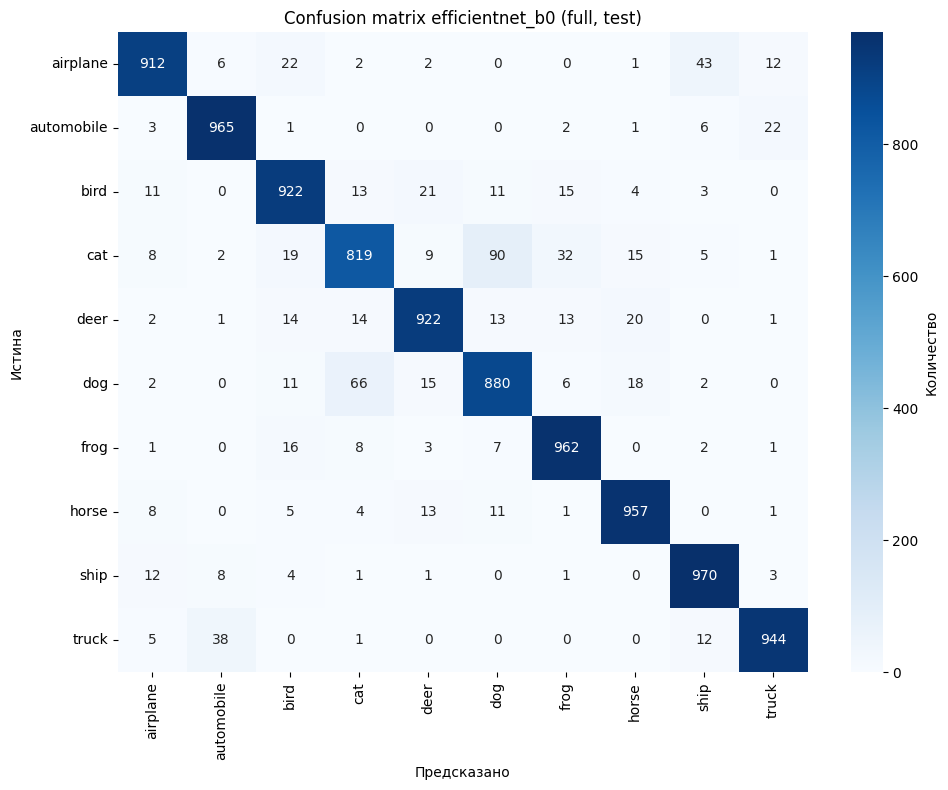

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = np.array(test_metrics["confusion"])

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASSES, yticklabels=CLASSES,
    cbar_kws={"label": "Количество"}
)
plt.xlabel("Предсказано")
plt.ylabel("Истина")
plt.title(f"Confusion matrix {chosen_backbone} ({best_resnet_mode}, test)")
plt.tight_layout()
plt.show()

Модель хорошо различает визуально разные классы (корабль, машина, лягушка recall выше 0.96), но путается на похожих: cat и dog (156 ошибок), airplane и ship (55 ошибок), truck и automobile (60 ошибок).

### Шумовой сдвиг и ошибки классификации

*Вес: 1 балл.*

**Постановка.** Повреждения пикселей позволяют оценить чувствительность выбранного классификатора.

Выполните следующие действия:
1. Примените шум к отложенным изображениям и измерьте accuracy.
2. Сохраните индексы фактических ошибочных предсказаний.

**Результат.** shift_metrics.json и errors.json с предсказаниями модели.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


In [ ]:
# превращаем батчи test_loader в зашумлённые, добавляя гауссовый шум
def noisy_batches(loader, sigma, seed=SEED):
    g = torch.Generator().manual_seed(seed)
    out = []
    for x, y in loader:
        noise = sigma * torch.randn(x.shape, generator=g)
        out.append((x + noise, y))
    return out


# прогоняем модель по списку батчей без обучения
@torch.no_grad()
def evaluate_batches(model, batches, device):
    model.eval()
    all_preds, all_labels = [], []
    for x, y in batches:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        all_preds.append(logits.argmax(1).cpu())
        all_labels.append(y.cpu())
    preds  = torch.cat(all_preds).numpy()
    labels = torch.cat(all_labels).numpy()
    acc = (preds == labels).mean()
    return acc, preds, labels


# применяем шум sigma = 0.1 и считаем accuracy
SIGMA_SHIFT = 0.1

# чистый test (для сравнения)
clean_acc, clean_preds, clean_labels = evaluate_batches(model, list(test_loader), DEVICE)

#зашумлённый test
noisy_b = noisy_batches(test_loader, sigma=SIGMA_SHIFT)
noisy_acc, noisy_preds, noisy_labels = evaluate_batches(model, noisy_b, DEVICE)

print(f"Чистый test:  acc = {clean_acc:.4f}")
print(f"Шум ={SIGMA_SHIFT}: acc = {noisy_acc:.4f}")
print(f"Падение = {clean_acc - noisy_acc:+.4f}")


# сохраняем метрики в shift_metrics.json
shift_metrics = {
    "sigma": SIGMA_SHIFT,
    "clean_acc": float(clean_acc),
    "noisy_acc": float(noisy_acc),
    "drop": float(clean_acc - noisy_acc),
    "backbone": chosen_backbone,
    "mode": best_resnet_mode,
}

with open(ARTIFACTS / "shift_metrics.json", "w") as f:
    json.dump(shift_metrics, f, indent=2)


# сохраняем индексы ошибок в errors.json
error_idx = np.where(noisy_preds != noisy_labels)[0]  # позиции где модель ошиблась

errors = [
    {
        "idx": int(i),
        "true": int(noisy_labels[i]),
        "pred": int(noisy_preds[i]),
        "true_class": CLASSES[int(noisy_labels[i])],
        "pred_class": CLASSES[int(noisy_preds[i])],
        "clean_pred": int(clean_preds[i]),# что модель говорила на чистой картинке
        "clean_right": bool(clean_preds[i] == clean_labels[i]),
    }
    for i in error_idx[:200] #сохраняем первые 200 ошибок
]

with open(ARTIFACTS / "errors.json", "w") as f:
    json.dump({
        "sigma": SIGMA_SHIFT,
        "n_errors": int(len(error_idx)),
        "n_total": int(len(noisy_labels)),
        "errors": errors,
    }, f, indent=2)

print(f"\nОшибок на зашумлённом test: {len(error_idx)} из {len(noisy_labels)}")


Чистый test:  acc = 0.9253
Шум =0.1: acc = 0.5055
Падение = +0.4198

Ошибок на зашумлённом test: 4945 из 10000


При добавлении небольшого шума (sigma=0.1) точность модели упала с 92.5% до 50.6%, то есть модель потеряла почти половину правильных ответов, и ошиблась на 4945 картинках из 10000.

### Профиль устойчивости к шуму

*Вес: 1 балл.*

**Постановка.** Одна интенсивность повреждения не описывает характер деградации.

Выполните следующие действия:
1. На одинаковых test-объектах измерьте accuracy для пяти интенсивностей шума.
2. Сохраните профиль деградации.

**Результат.** sigma_sensitivity.json с измеренной точностью.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


In [ ]:
# accuracy для 5 уровней интенсивности шума sigma
sigmas = [0.0, 0.05, 0.1, 0.2, 0.3]
sigma_profile = {}
for s in sigmas:
    if s == 0.0:
        batches = list(test_loader) # чистый test без шума
    else:
        batches = noisy_batches(test_loader, sigma=s)

    acc, _, _ = evaluate_batches(model, batches, DEVICE)
    sigma_profile[str(s)] = float(acc)
    print(f"sigma = {s:<5}  acc = {acc:.4f}")

# сохраняем профиль в sigma_sensitivity.json
with open(ARTIFACTS / "sigma_sensitivity.json", "w") as f:
    json.dump({
        "backbone": chosen_backbone,
        "mode": best_resnet_mode,
        "sigmas": sigmas,
        "accuracy": sigma_profile, }, f, indent=2)

sigma = 0.0    acc = 0.9253
sigma = 0.05   acc = 0.8099
sigma = 0.1    acc = 0.5055
sigma = 0.2    acc = 0.1060
sigma = 0.3    acc = 0.1044


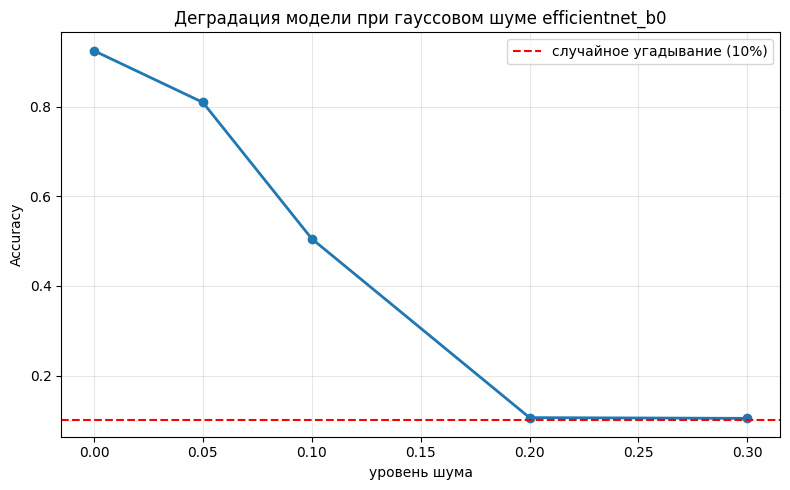

In [5]:
import matplotlib.pyplot as plt

sigmas_list = [float(s) for s in sigma_profile["sigmas"]]
accs = [sigma_profile["accuracy"][str(s)] for s in sigmas_list]

plt.figure(figsize=(8, 5))
plt.plot(sigmas_list, accs, marker="o", linewidth=2, color="#1f77b4")
plt.axhline(0.1, color="red", linestyle="--", label="случайное угадывание (10%)")
plt.xlabel("уровень шума")
plt.ylabel("Accuracy")
plt.title(f"Деградация модели при гауссовом шуме {chosen_backbone}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Модель отлично работает на чистых данных (92.5%), но очень быстро ломается от шума, при sigma=0.1 точность падает вдвое, а при sigma=0.2 превращается в случайное угадывание.

### Доля обучаемых параметров

*Вес: 1 балл.*

**Постановка.** Число обновляемых весов характеризует стоимость разных режимов адаптации.

Выполните следующие действия:
1. Посчитайте параметры каждого режима разморозки.
2. Проверьте порядок frozen, partial, full.

**Результат.** param_report.json с числами параметров трёх моделей.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


In [ ]:
# доля обучаемых параметров в каждом режиме
param_report = {}

for mode in ["frozen", "partial", "full"]:
    m = build_model("resnet18", mode) #собираем модель в этом режиме

    total = sum(p.numel() for p in m.parameters()) # всего параметров
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad) # обучаемых

    param_report[mode] = {
        "trainable": int(trainable), # параметры, которых учит оптимизатор
        "total": int(total), # сумма по всем параметрам модели
        "ratio": float(trainable / total), # доля обучаемых
    }

    print(f"{mode:<8} trainable = {trainable:>10,} / {total:,}  ({trainable/total:.2%})")

# проверка порядка
n_frozen  = param_report["frozen"]["trainable"]
n_partial = param_report["partial"]["trainable"]
n_full = param_report["full"]["trainable"]
print("\nПорядок правильный:", n_frozen < n_partial < n_full)

# сохраняем в param_report.jso
with open(ARTIFACTS / "param_report.json", "w") as f:
    json.dump(param_report, f, indent=2)


frozen   trainable =      5,130 / 11,181,642  (0.05%)
partial  trainable =  8,398,858 / 11,181,642  (75.11%)
full     trainable = 11,181,642 / 11,181,642  (100.00%)

Порядок правильный: True


У ResNet18 в режиме frozen обучается только голова 5 130 параметров (0.05% модели), в partial 8.4 млн (75%, голова + последний блок), а в full все 11.2 млн (100%). Порядок правильный. Чем больше разморожено, тем больше параметров учится и тем дольше происходит обучение.

### Поклассовые ошибки

*Вес: 1 балл.*

**Постановка.** Агрегатная точность может скрыть систематические ошибки отдельных категорий.

Выполните следующие действия:
1. Вычислите recall для каждого класса по test confusion matrix.
2. Найдите класс с наименьшим recall.

**Результат.** class_report.json с поклассовым recall и худшим классом.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


In [8]:
# берем матрицу ошибок из test_metrics
cm = np.array(test_metrics["confusion"]) # форма 10×10

# recall класса i = правильные ответы i / все картинки класса i
recall = cm.diagonal() / cm.sum(axis=1).clip(min=1)

# собираем отчет по классам
class_recall = {CLASSES[i]: float(recall[i]) for i in range(NUM_CLASSES)}

# худший класс
worst_class = CLASSES[int(np.argmin(recall))]
worst_recall = float(recall.min())

print("Recall по классам (test):")
for cls, r in sorted(class_recall.items(), key=lambda x: x[1]):
    print(f"{cls:<12} {r:.4f}")

print(f"\nХудший класс: {worst_class} (recall = {worst_recall:.4f})")

# сохраняем в class_report.json
class_report = {
    "backbone": chosen_backbone,
    "mode": best_resnet_mode,
    "test_acc": float(test_metrics["test_acc"]),
     "test_macro_f1": float(test_metrics["test_macro_f1"]),
    "recall": class_recall,
    "worst_class": worst_class,
    "worst_recall": worst_recall,
    "mean_recall": float(recall.mean()),
}

with open(ARTIFACTS / "class_report.json", "w") as f:
    json.dump(class_report, f, indent=2)


Recall по классам (test):
cat          0.8190
dog          0.8800
airplane     0.9120
bird         0.9220
deer         0.9220
truck        0.9440
horse        0.9570
frog         0.9620
automobile   0.9650
ship         0.9700

Худший класс: cat (recall = 0.8190)


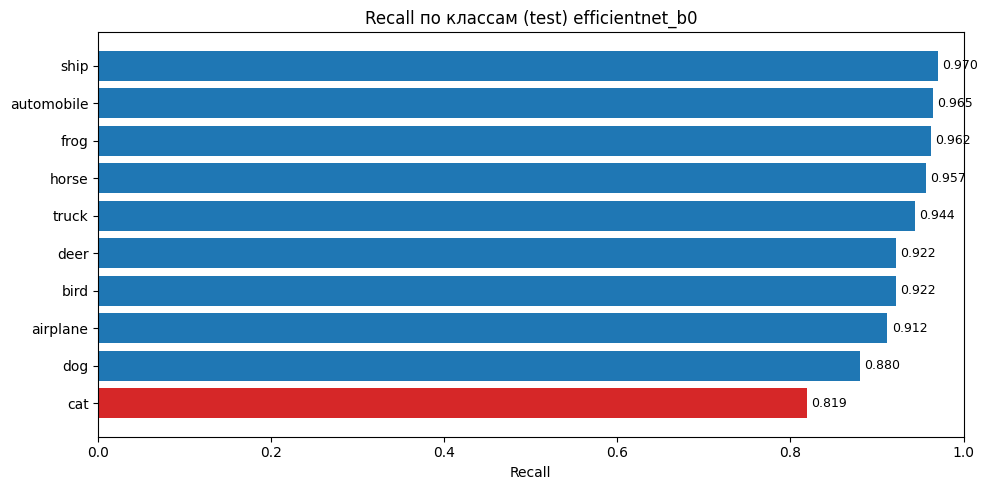

In [9]:
import matplotlib.pyplot as plt

recall = class_report["recall"]
sorted_items = sorted(recall.items(), key=lambda x: x[1])
names = [c for c, _ in sorted_items]
vals = [v for _, v in sorted_items]

colors = ["#d62728" if v == min(vals) else "#1f77b4" for v in vals]

plt.figure(figsize=(10, 5))
plt.barh(names, vals, color=colors)
plt.xlabel("Recall")
plt.title(f"Recall по классам (test) {chosen_backbone}")
plt.xlim(0, 1)
for i, v in enumerate(vals):
    plt.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

Хуже всего модель распознает котов (recall 81.9%). Лучше всего распознает корабли и машины (96–97%).

### Точность и стоимость обучения

*Вес: 1 балл.*

**Постановка.** Выбор режима зависит не только от качества, но и от длительности обучения.

Выполните следующие действия:
1. Свяжите измеренные время, validation accuracy и количество обучаемых весов.
2. Сохраните сопоставимую таблицу режимов.

**Результат.** efficiency_report.json с наблюдаемыми величинами.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


In [ ]:
import json

efficiency_report = {}

for key, r in results.items():
    # key например resnet18_frozen
    mode = r["mode"]

    trainable = r["n_trainable"]
    val_acc   = r["val_acc"]
    val_f1    = r["val_macro_f1"]
    time_sec  = r["train_time_sec"]

    efficiency_report[mode] = {
        "train_time_sec":  float(time_sec),
        "val_acc":         float(val_acc),
        "val_macro_f1":    float(val_f1),
        "n_trainable":     int(trainable),
        "acc_per_sec":     float(val_acc / max(time_sec, 1e-6)), # качество за секунду
    }

print(f"{'Режим':<8} {'Время, с':>10} {'Val Acc':>10} {'Macro-F1':>10} {'Обучаемых':>14} {'Acc/сек':>10}")
print("-" * 70)
for mode, m in efficiency_report.items():
    print(f"{mode:<8} {m['train_time_sec']:>10.1f} {m['val_acc']:>10.4f} "f"{m['val_macro_f1']:>10.4f} {m['n_trainable']:>14,} {m['acc_per_sec']:>10.6f}")

# сохраняем в efficiency_report.json
with open(ARTIFACTS / "efficiency_report.json", "w") as f:
    json.dump(efficiency_report, f, indent=2)


Режим      Время, с    Val Acc   Macro-F1      Обучаемых    Acc/сек
----------------------------------------------------------------------
frozen        815.3     0.7160     0.7151          5,130   0.000878
partial      1035.1     0.8910     0.8908      8,398,858   0.000861
full         1947.7     0.9060     0.9060     11,181,642   0.000465


frozen учится быстрее всех 815 сек, но дает качество всего 71.6%, а full учится в 2.5 раза дольше, зато дает лучший результат 90.6%. partial дает 89.1% качества за 1035 сек, то есть почти как full, но быстрее.

### Анализ ошибок при максимальном сдвиге

*Вес: 1 балл.*

**Постановка.** Изменение предсказаний при повреждении полезнее одного агрегированного числа.

Выполните следующие действия:
1. Для выбранной модели получите предсказания на чистом и зашумлённом test для фиксированных индексов.
2. Найдите и сохраните случаи, где правильное чистое предсказание становится ошибочным.

**Результат.** shift_failures.json с индексами и предсказаниями на реальных изображениях.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


In [2]:
# восстановление переменных из drive
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import json, random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

ARTIFACTS = Path("/content/drive/MyDrive/cv_lab1_artifacts")
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

IMG_SIZE = 128
BATCH_SIZE = 128
MEAN = (0.485, 0.456, 0.406)
STD  = (0.229, 0.224, 0.225)
NUM_CLASSES = 10
CLASSES = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

DATA_ROOT = Path("/content/data"); DATA_ROOT.mkdir(parents=True, exist_ok=True)
test_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
test_ds = datasets.CIFAR10(root=str(DATA_ROOT), train=False, download=True, transform=test_tf)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

def build_efficientnet(num_classes=NUM_CLASSES):
    net = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    net.classifier[1] = nn.Linear(net.classifier[1].in_features, num_classes)
    return net

model = build_efficientnet().to(DEVICE)
model.load_state_dict(torch.load(ARTIFACTS / "efficientnet_b0_full.pt", map_location=DEVICE))
model.eval()

with open(ARTIFACTS / "test_metrics.json") as f:
    test_metrics = json.load(f)
chosen_backbone  = test_metrics["backbone"]
best_resnet_mode = test_metrics["mode"]

with open(ARTIFACTS / "sigma_sensitivity.json") as f:
    sigma_profile = json.load(f)
sigmas = sigma_profile["sigmas"]

def noisy_batches(loader, sigma, seed=SEED):
    g = torch.Generator().manual_seed(seed)
    return [(x + sigma * torch.randn(x.shape, generator=g), y) for x, y in loader]

@torch.no_grad()
def evaluate_batches(model, batches, device):
    model.eval()
    all_preds, all_labels = [], []
    for x, y in batches:
        x, y = x.to(device), y.to(device)
        all_preds.append(model(x).argmax(1).cpu())
        all_labels.append(y.cpu())
    preds  = torch.cat(all_preds).numpy()
    labels = torch.cat(all_labels).numpy()
    return (preds == labels).mean(), preds, labels

print("Восстановление завершено")
print("chosen_backbone =", chosen_backbone)
print("best_resnet_mode =", best_resnet_mode)
print("sigmas =", sigmas)
print("SIGMA_MAX =", max(sigmas))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


100%|██████████| 170M/170M [29:20<00:00, 96.8kB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 74.5MB/s]


Восстановление завершено
chosen_backbone = efficientnet_b0
best_resnet_mode = full
sigmas = [0.0, 0.05, 0.1, 0.2, 0.3]
SIGMA_MAX = 0.3


In [ ]:
import numpy as np
import torch

# берем макс уровень шума из профиля
SIGMA_MAX = max(sigmas)
print(f"Максимальный уровень шума: sigma = {SIGMA_MAX}")

# чистые предсказания на всем test
clean_batches = list(test_loader)
clean_acc, clean_preds, clean_labels = evaluate_batches(model, clean_batches, DEVICE)
print(f"Чистый test: acc = {clean_acc:.4f}")

# зашумленные предсказания на тех же индексах
noisy_batches_max = noisy_batches(test_loader, sigma=SIGMA_MAX)
noisy_acc, noisy_preds, noisy_labels = evaluate_batches(model, noisy_batches_max, DEVICE)
print(f"Шум sigma={SIGMA_MAX}: acc = {noisy_acc:.4f}")

# находим случаи, когда на чистой картинке модель была права, на зашумленной ошиблась
clean_right = (clean_preds == clean_labels)# где чистое предсказание верное
noisy_wrong = (noisy_preds != noisy_labels) # где зашумленное предсказание неверное

# индексы где оба условия выполнены
flip_idx = np.where(clean_right & noisy_wrong)[0]

print(f"\nСлучаев было правильно и стало неправильно: {len(flip_idx)}")

# отчет по каждому случаю
shift_failures = []
for i in flip_idx[:200]:
    shift_failures.append({
        "idx": int(i),
        "true": int(clean_labels[i]),
        "true_class": CLASSES[int(clean_labels[i])],
        "clean_pred": int(clean_preds[i]),
        "clean_pred_class": CLASSES[int(clean_preds[i])],
        "noisy_pred": int(noisy_preds[i]),
        "noisy_pred_class": CLASSES[int(noisy_preds[i])],
    })
from collections import Counter
confusion_pairs = Counter((f["true_class"], f["noisy_pred_class"]) for f in shift_failures)
print("\nТоп-5 частых ошибок (истинный класс - предсказанный на шуме):")
for (t, p), cnt in confusion_pairs.most_common(5):
    print(f"  {t:<12} - {p:<12}  {cnt} раз")

# сохраняем в shift_failures.json
shift_failures_report = {
    "backbone": chosen_backbone,
    "mode": best_resnet_mode,
    "sigma": float(SIGMA_MAX),
    "clean_acc": float(clean_acc),
    "noisy_acc": float(noisy_acc),
    "n_flips": int(len(flip_idx)),
    "n_total": int(len(clean_labels)),
    "cases": shift_failures,
}

with open(ARTIFACTS / "shift_failures.json", "w") as f:
    json.dump(shift_failures_report, f, indent=2)


Максимальный уровень шума: sigma = 0.3
Чистый test: acc = 0.9253
Шум sigma=0.3: acc = 0.1044

Случаев было правильно и стало неправильно: 8304

Топ-5 частых ошибок (истинный класс - предсказанный на шуме):
  ship         - bird          25 раз
  horse        - bird          20 раз
  frog         - bird          18 раз
  truck        - bird          18 раз
  cat          - bird          15 раз


При сильном шуме модель сломалась почти полностью из 9253 правильных ответов уцелело меньше тысячи, а остальные 8304 превратились в ошибки. Причем почти все ошибки модель называет картинку птицей, хотя там были корабли, лошади и другие. То есть при сильном шуме модель просто перестает различать классы.

### Творческий бонус: новый тип сдвига

*Вес: 1 дополнительный балл.*

**Постановка.** Не все повреждения изображений похожи на гауссовский шум.

Выполните следующие действия:
1. Выберите воспроизводимое фотометрическое или геометрическое преобразование test-изображений.
2. Сравните точность с чистым test и приведите три конкретных примера изменения предсказания.

**Результат.** bonus_shift.json с описанием преобразования, метрикой и индексами примеров.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


In [ ]:
# Реализуйте это задание по постановке выше.
raise NotImplementedError("Реализуйте это задание в этой ячейке")


## Анализ результатов

Сопоставьте измеренные показатели на отложенных реальных данных. Укажите бюджет, ошибки модели и ограничения сокращённого запуска.

Я обучил две модели (ResNet18 и EfficientNet-B0) на 10 000 картинках CIFAR-10 и проверил на 10 000 отложенных картинках. Лучший результат EfficientNet-B0 в режиме full: 92.5% правильных ответов на тесте. Модель хорошо различает классы: хуже всего котов 82%, лучше всего корабли и машины 96–97%. Но есть большая проблема в том, что модель очень чувствительна к шуму и при слабом шуме 0.1 точность падает вдвое, а при сильном 0.3 до 10%, то есть модель просто перестает различать классы и называет почти все птицей. Бюджет обучения был ограничен: 10 000 картинок вместо 50 000, 3 эпохи и размер картинок 128 пикселей вместо 224, чтобы уложиться в разумное время на CPU. Из-за этого качество чуть ниже, чем могло быть на полном датасете с 224 пикселями.

## Выводы

Сформулируйте предметный вывод по сохранённым артефактам.

По сохранённым артефактам видно, что EfficientNet-B0 (full) это лучший выбор на тесте и он меньше по размеру. Режим full побеждает, так как чем больше слоев обучаем, тем лучше качество. Но при шуме модель ломается, значит она не устойчива к повреждениям и ее нужно дообучать, чтобы повысить устойчивость к шуму.



Ссылка на все артефакты (метрики и чекпоинты моделей)

https://drive.google.com/drive/folders/1xu4QIkLIJngE7qZPOosih2CWva6zFzT5?usp=drive_link